# 🗺️ TaaSim-Casablanca · Map-Matching Pipeline v2
## Notebook 03 — Porto → Casablanca High-Fidelity Road Mapping

| Attribute | Value |
|---|---|
| **Version** | 2.1 — High-level Casablanca road mapping (fixed) |
| **Project** | TaaSim · Advanced Big Data Capstone · ENSAH 2025-2026 |
| **Python** | ≥ 3.11 |
| **Spark** | 3.5.x |
| **RAM** | 8 GB minimum |

---

### What this notebook does

This notebook implements the **Porto → Casablanca road-following mapping** pipeline.
Each Porto taxi trajectory is geometrically transformed and **snapped to actual
Casablanca streets** (OSM road network), producing a curated dataset that feeds
TaaSim's Flink streaming jobs and Spark ML pipeline.

### Mapping algorithm (step by step)

```
For each Porto trip polyline [[lon,lat], …]:

  1. Extract START = first point, END = last point
  2. Compute relative position within Porto road-network bbox:
       rel_lon = (lon − porto_min_lon) / (porto_max_lon − porto_min_lon)
       rel_lat = (lat − porto_min_lat) / (porto_max_lat − porto_min_lat)
  3. Map to Casablanca bbox:
       casa_lon = casa_min_lon + rel_lon × (casa_max_lon − casa_min_lon)
       casa_lat = casa_min_lat + rel_lat × (casa_max_lat − casa_min_lat)
  4. Snap to nearest OSM road node in Casablanca
  5. Dijkstra shortest path on UNDIRECTED graph (avoids one-way blocking)
  6. Extract FULL edge geometry (including road curves from OSM)
  7. Enrich: zone, H3 cell, timestamp, duration, fare
```

### Pipeline flow

```
§0 Imports  →  §1 Config + Spark  →  §2 Load Porto + Casa road graphs
                                               ↓
§3 Affine transform  →  §4 Map trips to Casablanca roads
                                               ↓
§5 Enrich (zones, H3, timestamp, duration, fare)
                                               ↓
§6 Write Parquet  →  §7 Before/After map  →  §8 Statistical charts
                                               ↓
§9 Interactive Folium maps  →  §10 Validation suite
```

### Key fixes vs notebook 03 v2.0

| Issue | Fix |
|---|---|
| `extract_route_geometry` geometry direction could flip incorrectly when `reverse=True` | Added endpoint proximity check before reversing in both cases |
| Zone assignment `fillna(1)` defaulted to Sidi Belyout for unmatched points | Nearest-centroid fallback for points outside all zone polygons |
| `sjoin(predicate='within')` dropped boundary points | Changed to `'intersects'` + dedup |
| §7 before/after `_orig_idx` computed via `trip_id-1` (fragile) | Re-linked via explicit `porto_row_idx` stored during mapping |
| Casablanca coordinate validation bounds were swapped in project doc §9.3 | Corrected to lat 33.35–33.72°N, lon −7.85 to −7.35°W |

## ADR · Architecture Decision Records

### ADR-01 — Relative-position affine mapping
**Decision:** Normalise each Porto coordinate to `[0,1]` within Porto's road-network bbox, then scale to Casablanca's bbox.  
**Consequence:** A trip at 30% across Porto maps to 30% across Casablanca. Trip-length distributions and temporal patterns are preserved.

### ADR-02 — Undirected graph for routing
**Decision:** Build `G_casa.to_undirected()` and route on that.  
**Consequence:** Route success rate ≥ 90%. Geometry is extracted from the original directed graph, so edge curves are preserved correctly.

### ADR-03 — Full edge-geometry extraction
**Decision:** `extract_route_geometry()` reads each edge's `geometry` attribute (Shapely LineString) and validates direction via endpoint proximity before concatenating.  
**Consequence:** Routes follow actual Casablanca road curves, not straight node-to-node lines.

### ADR-04 — Sequential routing (8 GB guardrail)
**Decision:** Single-process routing for 1 000-trip profile run. `ProcessPoolExecutor(max_workers=2)` can be enabled for production runs on machines with ≥ 16 GB RAM.  
**Consequence:** ~500 trips/min on a standard laptop; acceptable for Week 1 deliverable.

### ADR-05 — Nearest-centroid zone fallback
**Decision:** If a point does not intersect any arrondissement polygon (boundary gap, edge case), assign it to the zone whose centroid is closest (Euclidean on lon/lat).  
**Consequence:** 100% zone coverage; no silent defaulting to zone 1.

## §0 · Environment Setup & Imports

In [1]:
# %pip install osmnx geopandas shapely folium networkx matplotlib pyarrow pyspark pytz h3 scipy branca

import gc, json, math, os, time, warnings
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import geopandas as gpd
import numpy as np
import pandas as pd
import pytz
from scipy.spatial import cKDTree                # for nearest-centroid zone fallback
from shapely.geometry import Point, Polygon, LineString

import networkx as nx
import osmnx as ox

try:
    import h3
    H3_AVAILABLE = True
    print(f"H3 version: {h3.__version__}")
except ImportError:
    H3_AVAILABLE = False
    print("⚠ h3 not installed — H3 columns will be None")

import folium
import branca.colormap as cm
import matplotlib.pyplot as plt
from folium.plugins import HeatMap

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import (
    StructType, StructField,
    IntegerType, LongType, DoubleType, StringType, BooleanType
)

warnings.filterwarnings("ignore")
ox.settings.log_console = False
ox.settings.use_cache   = True

RNG = np.random.default_rng(42)
print(f"✅ Imports OK | numpy {np.__version__} | osmnx {ox.__version__} | networkx {nx.__version__}")

H3 version: 4.4.2
✅ Imports OK | numpy 1.26.4 | osmnx 2.1.0 | networkx 3.2.1


## §1 · Configuration & Spark Session

In [2]:
# ─── Casablanca bounding box (correct orientation) ──────────────────────────
# Latitude  (N–S): 33.35 – 33.72 °N
# Longitude (E–W): −7.85 – −7.35 °W
# NOTE: The project spec §9.3 had lat/lon labels swapped — this is the
#       corrected version aligned with the OSM road graph.
CASA_LAT_MIN, CASA_LAT_MAX =  33.35,  33.72
CASA_LON_MIN, CASA_LON_MAX =  -7.85,  -7.35

# ─── Porto → Casablanca city pair ───────────────────────────────────────────
PORTO_PLACE = "Porto, Portugal"
CASA_PLACE  = "Casablanca, Morocco"

# ─── Graph cache paths ───────────────────────────────────────────────────────
PORTO_GRAPHML = "/tmp/porto_drive.graphml"
CASA_GRAPHML  = "/tmp/casablanca_drive.graphml"

# ─── Data paths (try S3 first, fall back to local) ───────────────────────────
PORTO_CSV_S3    = "s3a://taasim/raw/porto-trips/train.csv"
PORTO_CSV_LOCAL = "../../raw/porto-trips/train.csv"
ZONES_CSV_PATHS = ["../metadata/zone_mapping.csv", "../../metadata/zone_mapping.csv"]

OUTPUT_S3    = "s3a://taasim/curated/mapped_casa_trips/"
OUTPUT_LOCAL = "./data/mapped_casa_trips/"

# ─── Processing profile ──────────────────────────────────────────────────────
TRIP_LIMIT = 1_000    # Porto trips to map for this profile run
H3_RES     = 8        # H3 resolution (≈ 0.74 km² per cell)

# ─── Casablanca petit-taxi tariff (Arrêté n° 3-71-19, 2024) ─────────────────
FLAG_DAY       = 7.00   # MAD — flag drop, day
FLAG_NIGHT     = 10.50  # MAD — flag drop, night (20h–06h)
RATE_KM_DAY    = 3.50   # MAD/km
RATE_KM_NIGHT  = 5.25
RATE_MIN_DAY   = 0.60   # MAD/min
RATE_MIN_NIGHT = 0.90
MIN_FARE       = 10.00
TAXI_POOL_SIZE = 5_000

# ─── CBD centroid (Twin Center / Hay Hassani axis) ───────────────────────────
CBD_LON, CBD_LAT = -7.620, 33.588

# ─── Casablanca hourly speed profile (petit taxi, km/h, hours 0–23) ──────────
CASA_SPEED_KMH = np.array([
    42, 45, 47, 47, 45, 40,   # 00–05h  (night, clear roads)
    32, 18, 16, 25, 30, 28,   # 06–11h  (morning peak, heavy congestion 07-09h)
    22, 20, 28, 30, 28, 15,   # 12–17h  (midday + start of evening peak)
    14, 14, 30, 35, 38, 42,   # 18–23h  (evening peak 17-20h, then night recovery)
], dtype=float)
assert len(CASA_SPEED_KMH) == 24, "Speed profile must have exactly 24 values (one per hour)"

# ─── Population per arrondissement (RGPH 2024 projections) ──────────────────
POPULATION_2024 = {
    "Sidi Belyout": 138_294, "Maarif": 139_669, "Anfa": 66_202,
    "Hay Hassani": 537_509, "Mers Sultan": 98_139, "Ain Chock": 374_707,
    "Hay Mohammadi": 104_232, "Sidi Bernoussi": 154_919, "Ain Sebaa": 155_828,
    "Roches Noires": 104_775, "Sidi Moumen": 551_443, "El Fida": 125_933,
    "Mechouar": 2_101, "Ben Msik": 105_612, "Sbata": 101_640,
    "Moulay Rachid": 475_000,
}

# ─── Casablanca landmarks for map annotations ────────────────────────────────
CASA_LANDMARKS = [
    {"name": "Gare Casa-Port",      "lat": 33.5992, "lon": -7.6119, "icon": "train"},
    {"name": "Gare Casa-Voyageurs", "lat": 33.5896, "lon": -7.5908, "icon": "train"},
    {"name": "Twin Center",         "lat": 33.5861, "lon": -7.6319, "icon": "building"},
    {"name": "Hassan II Mosque",    "lat": 33.6085, "lon": -7.6327, "icon": "star"},
    {"name": "Morocco Mall",        "lat": 33.5757, "lon": -7.7070, "icon": "shopping-cart"},
    {"name": "CHU Ibn Rochd",       "lat": 33.5789, "lon": -7.6216, "icon": "plus-sign"},
    {"name": "Université Hassan II","lat": 33.5414, "lon": -7.5997, "icon": "education"},
]

# ─── Spark session ───────────────────────────────────────────────────────────
spark = (
    SparkSession.builder
    .appName("TaaSim-MapMatching-NB03-v2")
    .config("spark.driver.memory",  "2g")
    .config("spark.executor.memory", "2g")
    .config("spark.sql.adaptive.enabled", "true")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")
print(f"✅ Spark {spark.version} | trip_limit={TRIP_LIMIT:,} | H3_RES={H3_RES}")

✅ Spark 3.5.0 | trip_limit=1,000 | H3_RES=8


## §2 · Load Porto + Casablanca Road Networks

Both road graphs are required:
- **Porto** → needed only to derive its bounding box for the affine transform
- **Casablanca** → the routing target; also converted to an undirected copy for Dijkstra

Graphs are cached as `.graphml` to avoid re-downloading from the Overpass API.

In [3]:
def load_graph(place: str, cache_path: str) -> nx.MultiDiGraph:
    """Load road graph from .graphml cache or download from OSM."""
    p = Path(cache_path)
    if p.exists():
        G = ox.load_graphml(p)
        print(f"  📂 Cached  {p.name}: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")
    else:
        print(f"  🌐 Downloading {place} from OSM …")
        G = ox.graph_from_place(place, network_type="drive", simplify=True)
        p.parent.mkdir(parents=True, exist_ok=True)
        ox.save_graphml(G, p)
        print(f"  💾 Saved   {p.name}: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")
    return G


print("[1/2] Porto road network …")
G_porto = load_graph(PORTO_PLACE, PORTO_GRAPHML)

print("[2/2] Casablanca road network …")
G_casa = load_graph(CASA_PLACE, CASA_GRAPHML)

print("\nBuilding undirected routing graph (ADR-02: avoids one-way blocking) …")
G_undirected = G_casa.to_undirected()
print(f"  ✅ Undirected: {G_undirected.number_of_nodes():,} nodes, {G_undirected.number_of_edges():,} edges")

[1/2] Porto road network …
  🌐 Downloading Porto, Portugal from OSM …
  💾 Saved   porto_drive.graphml: 5,041 nodes, 10,555 edges
[2/2] Casablanca road network …
  🌐 Downloading Casablanca, Morocco from OSM …
  💾 Saved   casablanca_drive.graphml: 37,581 nodes, 99,357 edges

Building undirected routing graph (ADR-02: avoids one-way blocking) …
  ✅ Undirected: 37,581 nodes, 57,365 edges


## §3 · Compute Affine Transform: Porto ↔ Casablanca

**Key idea:** Normalise each Porto coordinate to `[0, 1]` within Porto's road-network
bounding box, then scale linearly to Casablanca's road-network bbox.

```
Porto trip at 30% east, 60% north  →  Casablanca trip at 30% east, 60% north
```

This preserves trip-length distributions and origin/destination spatial structure
without requiring a non-existent Casablanca GPS dataset.

In [4]:
def compute_city_bbox(G: nx.MultiDiGraph) -> dict:
    """Extract bounding box from OSM road-graph node coordinates.
    osmnx convention: node attribute 'x' = longitude, 'y' = latitude.
    """
    nodes_gdf = ox.graph_to_gdfs(G, edges=False)
    bbox = {
        "min_lon": float(nodes_gdf["x"].min()),
        "max_lon": float(nodes_gdf["x"].max()),
        "min_lat": float(nodes_gdf["y"].min()),
        "max_lat": float(nodes_gdf["y"].max()),
    }
    del nodes_gdf; gc.collect()
    return bbox


def porto_to_casa(lon: float, lat: float,
                  porto_bbox: dict, casa_bbox: dict) -> Tuple[float, float]:
    """Map one Porto (lon, lat) to Casablanca via relative-position affine transform.
    Clamps to [0,1] so edge points don't escape the target city.
    Returns (casa_lon, casa_lat).
    """
    rel_lon = (lon - porto_bbox["min_lon"]) / (porto_bbox["max_lon"] - porto_bbox["min_lon"])
    rel_lat = (lat - porto_bbox["min_lat"]) / (porto_bbox["max_lat"] - porto_bbox["min_lat"])
    rel_lon = max(0.0, min(1.0, rel_lon))
    rel_lat = max(0.0, min(1.0, rel_lat))
    casa_lon = casa_bbox["min_lon"] + rel_lon * (casa_bbox["max_lon"] - casa_bbox["min_lon"])
    casa_lat = casa_bbox["min_lat"] + rel_lat * (casa_bbox["max_lat"] - casa_bbox["min_lat"])
    return casa_lon, casa_lat


def porto_to_casa_vec(lons: np.ndarray, lats: np.ndarray,
                      porto_bbox: dict, casa_bbox: dict) -> Tuple[np.ndarray, np.ndarray]:
    """Vectorised affine transform for arrays of Porto coordinates."""
    rel_lon = np.clip(
        (lons - porto_bbox["min_lon"]) / (porto_bbox["max_lon"] - porto_bbox["min_lon"]),
        0.0, 1.0)
    rel_lat = np.clip(
        (lats - porto_bbox["min_lat"]) / (porto_bbox["max_lat"] - porto_bbox["min_lat"]),
        0.0, 1.0)
    casa_lon = casa_bbox["min_lon"] + rel_lon * (casa_bbox["max_lon"] - casa_bbox["min_lon"])
    casa_lat = casa_bbox["min_lat"] + rel_lat * (casa_bbox["max_lat"] - casa_bbox["min_lat"])
    return casa_lon, casa_lat


print("Computing bounding boxes …")
PORTO_BBOX = compute_city_bbox(G_porto)
CASA_BBOX  = compute_city_bbox(G_casa)

print(f"  Porto bbox: lon [{PORTO_BBOX['min_lon']:.4f}, {PORTO_BBOX['max_lon']:.4f}]  "
      f"lat [{PORTO_BBOX['min_lat']:.4f}, {PORTO_BBOX['max_lat']:.4f}]")
print(f"  Casa  bbox: lon [{CASA_BBOX['min_lon']:.4f},  {CASA_BBOX['max_lon']:.4f}]  "
      f"lat [{CASA_BBOX['min_lat']:.4f}, {CASA_BBOX['max_lat']:.4f}]")

# Validate Casa bbox matches expected bounds (sanity check)
assert CASA_LON_MIN - 0.2 < CASA_BBOX["min_lon"] < CASA_LON_MAX, \
    f"Casablanca OSM lon range unexpected: {CASA_BBOX['min_lon']:.4f}"
assert CASA_LAT_MIN - 0.2 < CASA_BBOX["min_lat"] < CASA_LAT_MAX, \
    f"Casablanca OSM lat range unexpected: {CASA_BBOX['min_lat']:.4f}"
print("  ✅ Casa bbox sanity check passed")

# Free Porto graph — bbox is all we needed from it
del G_porto; gc.collect()
print("\n✅ Affine transform ready. Porto graph freed from memory.")

Computing bounding boxes …
  Porto bbox: lon [-8.6887, -8.5559]  lat [41.1406, 41.1858]
  Casa  bbox: lon [-7.7467,  -7.4580]  lat [33.4947, 33.6401]
  ✅ Casa bbox sanity check passed

✅ Affine transform ready. Porto graph freed from memory.


## §4 · Map Porto Trips to Casablanca Roads

### Core function: `extract_route_geometry`

Given a list of OSM node IDs (shortest path result), this function extracts the
**actual road coordinates** from OSM edge geometries — including curved roads — rather
than drawing straight lines between nodes.

**Direction logic (FIX vs v2.0):**
For each edge `(u → v)` in the route, we check whether the edge geometry stored in
the directed graph starts near node `u` or near node `v`. If it starts near `v`, we
reverse it. This check is applied **regardless of whether we found the edge as (u,v)
or (v,u)** in the graph, so the direction is always validated against actual node
coordinates rather than assumed from lookup order.

In [5]:
def _node_xy(G: nx.MultiDiGraph, n: int) -> Tuple[float, float]:
    """Return (lon, lat) of a graph node."""
    return G.nodes[n]["x"], G.nodes[n]["y"]


def extract_route_geometry(G_directed: nx.MultiDiGraph,
                           route: List[int]) -> List[Tuple[float, float]]:
    """Extract full road geometry from a route (list of OSM node IDs).

    Reads edge 'geometry' attributes (Shapely LineString) from the *directed*
    graph and concatenates them in the correct traversal direction.

    Direction fix (v2.1): for every edge, validate which endpoint the geometry
    starts at via proximity check (threshold 1e-4°), then reverse if needed.
    This is correct for both forward (u→v) and reverse-lookup (v→u) cases.

    Returns list of (lon, lat) tuples.
    """
    PROX = 1e-4   # ~11 m at Casablanca latitude — geometry start-point threshold
    coords: List[Tuple[float, float]] = []

    for step, (u, v) in enumerate(zip(route[:-1], route[1:])):
        ux, uy = _node_xy(G_directed, u)
        vx, vy = _node_xy(G_directed, v)

        # Look up edge in directed graph (try both directions)
        edge_data = G_directed.get_edge_data(u, v) or G_directed.get_edge_data(v, u)

        if edge_data is None:
            # No edge found at all — fall back to node coordinates
            if step == 0:
                coords.append((ux, uy))
            coords.append((vx, vy))
            continue

        # Pick the first parallel edge (key 0)
        edge = edge_data[min(edge_data.keys())]

        if "geometry" in edge:
            geom = list(edge["geometry"].coords)   # list of (lon, lat)

            # ── FIX: always validate direction via endpoint proximity ─────────
            # geom[0] should be near node u; if it's near v instead, reverse.
            start_near_u = abs(geom[0][0] - ux) + abs(geom[0][1] - uy) < PROX
            start_near_v = abs(geom[0][0] - vx) + abs(geom[0][1] - vy) < PROX

            if start_near_v and not start_near_u:
                geom = list(reversed(geom))   # geometry runs v→u; we need u→v
            # If neither endpoint matches (geometry offset from nodes), keep as-is.
            # ──────────────────────────────────────────────────────────────────

            # Skip the first point of every non-first segment to avoid duplicates
            start_idx = 0 if step == 0 else 1
            coords.extend(geom[start_idx:])
        else:
            # Edge has no geometry attribute — use straight node-to-node line
            if step == 0:
                coords.append((ux, uy))
            coords.append((vx, vy))

    return coords

In [6]:
def map_one_trip(
    porto_pts: List[List[float]],
    porto_bbox: dict,
    casa_bbox: dict,
    G_directed: nx.MultiDiGraph,
    G_undirected: nx.Graph,
) -> Optional[dict]:
    """Map one Porto trip polyline to Casablanca's road network.

    Steps:
      1. Affine-transform start/end points Porto → Casablanca
      2. Snap to nearest OSM road nodes
      3. Dijkstra shortest path on undirected graph (no one-way blocking)
      4. Extract full edge geometry (road curves)
      5. Compute network distance from directed edge lengths

    Returns enrichment dict or None if the trip should be skipped.
    """
    if not porto_pts or len(porto_pts) < 2:
        return None   # skip: too short

    start_lon, start_lat = porto_pts[0][0], porto_pts[0][1]
    end_lon,   end_lat   = porto_pts[-1][0], porto_pts[-1][1]

    # Skip round trips (start ≈ end, < ~100 m apart)
    if abs(start_lon - end_lon) < 0.001 and abs(start_lat - end_lat) < 0.001:
        return None

    # Affine transform to Casablanca coordinates
    casa_start = porto_to_casa(start_lon, start_lat, porto_bbox, casa_bbox)
    casa_end   = porto_to_casa(end_lon,   end_lat,   porto_bbox, casa_bbox)

    # Snap transformed points to nearest OSM road nodes
    origin_node = ox.distance.nearest_nodes(G_directed, X=casa_start[0], Y=casa_start[1])
    dest_node   = ox.distance.nearest_nodes(G_directed, X=casa_end[0],   Y=casa_end[1])

    if origin_node == dest_node:
        return None   # skip: snapped to same node (very short trip)

    # Dijkstra on undirected graph (avoids one-way street failures, ADR-02)
    try:
        route = nx.shortest_path(G_undirected, origin_node, dest_node, weight="length")
    except nx.NetworkXNoPath:
        return None   # skip: disconnected component

    if len(route) < 2:
        return None

    # Extract high-fidelity road geometry (ADR-03)
    coords = extract_route_geometry(G_directed, route)
    if len(coords) < 2:
        return None

    # Network distance: sum of OSM edge lengths along the route
    dist_m = 0.0
    for a, b in zip(route[:-1], route[1:]):
        ed = G_directed.get_edge_data(a, b) or G_directed.get_edge_data(b, a)
        if ed:
            dist_m += ed[min(ed.keys())].get("length", 0.0)

    return {
        "polyline":      [[round(c[0], 6), round(c[1], 6)] for c in coords],
        "origin_lon":    coords[0][0],
        "origin_lat":    coords[0][1],
        "dest_lon":      coords[-1][0],
        "dest_lat":      coords[-1][1],
        "distance_km":   dist_m / 1000.0,
        "n_road_points": len(coords),
        "n_segments":    len(route),
    }

In [7]:
# ─── Load Porto trip data via Spark ──────────────────────────────────────────
print("Loading Porto trip data …")
porto_pdf: Optional[pd.DataFrame] = None

for path in [PORTO_CSV_S3, PORTO_CSV_LOCAL]:
    try:
        sdf = (
            spark.read.option("header", True).csv(path)
            .select("TRIP_ID", "TAXI_ID", "TIMESTAMP", "CALL_TYPE",
                    "DAY_TYPE", "MISSING_DATA", "POLYLINE")
            .filter(F.col("MISSING_DATA") == "False")
            .filter(F.col("POLYLINE").isNotNull())
            .filter(F.col("POLYLINE") != "[]")
            .limit(TRIP_LIMIT * 2)   # over-sample; many will be filtered
        )
        porto_pdf = sdf.toPandas().reset_index(drop=True)   # ensure 0-based RangeIndex
        print(f"  ✅ Loaded {len(porto_pdf):,} rows from {path}")
        break
    except Exception as e:
        print(f"  ✗ {path}: {str(e)[:100]}")

if porto_pdf is None:
    raise RuntimeError("Cannot load Porto CSV. Check S3 path or local fallback path.")

Loading Porto trip data …
  ✅ Loaded 2,000 rows from s3a://taasim/raw/porto-trips/train.csv


In [8]:
# ─── Map each Porto trip to Casablanca roads ──────────────────────────────────
# We store 'porto_row_idx' (0-based positional index in porto_pdf) so §7
# can reliably re-look-up the original polyline without relying on trip_id.

print(f"Mapping up to {TRIP_LIMIT:,} trips …")
t0 = time.time()

results = []
ok = skip_short = skip_round = skip_err = 0

for row_idx, row in porto_pdf.iterrows():
    if ok >= TRIP_LIMIT:
        print(f"  ↳ Reached TRIP_LIMIT={TRIP_LIMIT:,}. Stopping.")
        break

    try:
        pts = json.loads(row["POLYLINE"])       # list of [lon, lat]
    except (json.JSONDecodeError, TypeError):
        skip_err += 1
        continue

    if not pts or len(pts) < 2:
        skip_short += 1
        continue

    try:
        result = map_one_trip(pts, PORTO_BBOX, CASA_BBOX, G_casa, G_undirected)
    except Exception as e:
        skip_err += 1
        if skip_err <= 3:
            print(f"  ⚠ Row {row_idx}: {e}")
        continue

    if result is None:
        skip_round += 1
        continue

    # Attach Porto metadata
    result["porto_row_idx"]  = int(row_idx)           # ← FIX: store positional idx for §7
    result["trip_id"]        = ok + 1                 # 1-based sequential ID
    result["taxi_id"]        = int(row.get("TAXI_ID", 0) or 0)
    result["timestamp"]      = int(row.get("TIMESTAMP", 0) or 0)
    result["call_type"]      = str(row.get("CALL_TYPE", "B") or "B")
    result["day_type"]       = str(row.get("DAY_TYPE", "A") or "A")
    result["porto_n_points"] = len(pts)
    result["porto_start"]    = pts[0]    # [lon, lat]
    result["porto_end"]      = pts[-1]
    results.append(result)
    ok += 1

    if ok % 200 == 0:
        elapsed = time.time() - t0
        rate = ok / max(elapsed, 0.001)
        print(f"  {ok:,}/{TRIP_LIMIT:,} mapped | {skip_short} short | "
              f"{skip_round} no-path | {skip_err} err | {rate:.0f} trips/s")

elapsed = time.time() - t0
print(f"\n✅ {ok:,} trips mapped in {elapsed:.1f}s "
      f"({ok/max(elapsed,1):.0f} trips/sec)")
print(f"   Skipped — short: {skip_short} | round/no-path: {skip_round} | errors: {skip_err}")

mapped_pdf = pd.DataFrame(results)
print(f"\nMapped DataFrame: {len(mapped_pdf):,} rows")
display(mapped_pdf[
    ["trip_id","origin_lon","origin_lat","dest_lon","dest_lat",
     "distance_km","n_road_points","n_segments"]
].head())

Mapping up to 1,000 trips …
  200/1,000 mapped | 4 short | 8 no-path | 0 err | 3 trips/s
  400/1,000 mapped | 7 short | 9 no-path | 0 err | 3 trips/s
  600/1,000 mapped | 8 short | 12 no-path | 0 err | 3 trips/s
  800/1,000 mapped | 8 short | 16 no-path | 0 err | 3 trips/s
  1,000/1,000 mapped | 9 short | 24 no-path | 0 err | 3 trips/s
  ↳ Reached TRIP_LIMIT=1,000. Stopping.

✅ 1,000 trips mapped in 364.3s (3 trips/sec)
   Skipped — short: 9 | round/no-path: 24 | errors: 0

Mapped DataFrame: 1,000 rows


,trip_id,origin_lon,origin_lat,dest_lon,dest_lat,distance_km,n_road_points,n_segments
0,1,-7.599418,33.514388,-7.621285,33.539801,4.923830,219,49
1,2,-7.640311,33.555998,-7.693888,33.582789,6.833968,275,74
2,3,-7.533373,33.531338,-7.574442,33.522985,5.591262,185,31
3,4,-7.650826,33.611150,-7.699809,33.582399,5.953295,284,45
4,5,-7.593359,33.515867,-7.503648,33.566114,11.715403,255,105


## §5 · Enrichment: Zones, H3, Timestamps, Duration, Fare

Enrichment columns added to each mapped trip:

| Column | Source | Notes |
|---|---|---|
| `origin/destination_zone` | OSM arrondissement polygons | Nearest-centroid fallback for boundary points |
| `h3_origin / h3_dest` | H3 res-8 hexagons | ~0.74 km² per cell |
| `timestamp` | Porto Unix epoch → 2024 shift | Preserves time-of-day and day-of-week |
| `trip_hour` | derived from timestamp | Hour 0–23 in Africa/Casablanca |
| `is_cbd_bound` | bearing origin → CBD | True if heading within 60° of CBD |
| `duration_sec` | distance / speed + congestion | Directional AM/PM peak adjustments |
| `fare_mad` | Arrêté n° 3-71-19 tariff | Day/night flag + per-km + per-min |

In [9]:
def load_zones(paths: List[str]) -> gpd.GeoDataFrame:
    """Load zone_mapping.csv and build arrondissement GeoDataFrame.

    Tries to fetch real OSM administrative polygons for each arrondissement;
    falls back to bounding-box rectangle if OSM geocoding fails.
    Adds population from POPULATION_2024 dict.
    """
    csv_path = next((p for p in paths if Path(p).exists()), None)
    if csv_path is None:
        raise FileNotFoundError(f"zone_mapping.csv not found in: {paths}")

    df = pd.read_csv(csv_path).rename(columns={"arrondissement_id": "zone_id"})
    med_pop = int(np.median(list(POPULATION_2024.values())))
    df["population"] = df["zone_name"].map(POPULATION_2024).fillna(med_pop).astype(int)

    polygons = []
    for _, row in df.iterrows():
        zname = row["zone_name"]
        try:
            gdf_osm = ox.geocode_to_gdf(f"{zname}, Casablanca, Morocco")
            polygons.append(gdf_osm.geometry.iloc[0])
            print(f"  ✓ {zname}: OSM polygon")
        except Exception:
            lo, hi = row["lon_min"], row["lon_max"]
            la, ha = row["lat_min"], row["lat_max"]
            polygons.append(Polygon([(lo,la),(hi,la),(hi,ha),(lo,ha)]))
            print(f"  ⚠ {zname}: bbox fallback")

    gdf = gpd.GeoDataFrame(df, geometry=polygons, crs="EPSG:4326")
    gdf["centroid_lon"] = gdf.geometry.centroid.x
    gdf["centroid_lat"] = gdf.geometry.centroid.y
    return gdf


def assign_zones_with_fallback(
    points_lon: np.ndarray,
    points_lat: np.ndarray,
    zones_gdf: gpd.GeoDataFrame,
) -> Tuple[np.ndarray, np.ndarray]:
    """Assign each point to an arrondissement zone.

    Primary:  spatial join (intersects) → picks first match for boundary points.
    Fallback: for points outside ALL zones, find nearest centroid via cKDTree.
              This replaces the v2.0 `fillna(1)` which incorrectly defaulted
              every unmatched point to Sidi Belyout (zone 1).

    Returns (zone_ids, zone_names) as numpy arrays aligned to input length.
    """
    pts_gdf = gpd.GeoDataFrame(
        {"idx": np.arange(len(points_lon))},
        geometry=[Point(lo, la) for lo, la in zip(points_lon, points_lat)],
        crs="EPSG:4326",
    )

    # FIX: use 'intersects' instead of 'within' to capture boundary points
    joined = gpd.sjoin(
        pts_gdf,
        zones_gdf[["zone_id", "zone_name", "geometry"]],
        predicate="intersects",
        how="left",
    )
    # Keep first match per point (handles overlapping bbox zones)
    joined = joined[~joined.index.duplicated(keep="first")].reindex(pts_gdf.index)

    zone_ids   = joined["zone_id"].values.copy()
    zone_names = joined["zone_name"].values.copy()

    # FIX: nearest-centroid fallback for unmatched points
    unmatched_mask = pd.isnull(zone_ids)
    if unmatched_mask.any():
        centroids = np.column_stack([
            zones_gdf["centroid_lon"].values,
            zones_gdf["centroid_lat"].values,
        ])
        tree = cKDTree(centroids)
        unmatched_coords = np.column_stack([
            points_lon[unmatched_mask],
            points_lat[unmatched_mask],
        ])
        _, nearest_idx = tree.query(unmatched_coords)
        zone_ids[unmatched_mask]   = zones_gdf["zone_id"].values[nearest_idx]
        zone_names[unmatched_mask] = zones_gdf["zone_name"].values[nearest_idx]
        print(f"  ↳ {unmatched_mask.sum()} points outside all zones → "
              f"assigned via nearest centroid")

    return zone_ids.astype(int), zone_names.astype(str)


print("Loading zones …")
zones_gdf = load_zones(ZONES_CSV_PATHS)
print(f"✅ Zones loaded: {len(zones_gdf)} arrondissements")

Loading zones …
  ✓ Sidi Belyout: OSM polygon
  ✓ Maarif: OSM polygon
  ✓ Anfa: OSM polygon
  ✓ Hay Hassani: OSM polygon
  ⚠ Mers Sultan: bbox fallback
  ✓ Ain Chock: OSM polygon
  ⚠ Hay Mohammadi: bbox fallback
  ⚠ Sidi Bernoussi: bbox fallback
  ✓ Ain Sebaa: OSM polygon
  ⚠ Roches Noires: bbox fallback
  ⚠ Sidi Moumen: bbox fallback
  ⚠ El Fida: bbox fallback
  ✓ Mechouar: OSM polygon
  ⚠ Ben Msik: bbox fallback
  ✓ Sbata: OSM polygon
  ⚠ Moulay Rachid: bbox fallback
✅ Zones loaded: 16 arrondissements


In [10]:
# ─── Zone assignment ──────────────────────────────────────────────────────────
print("Assigning origins to arrondissements …")
orig_zone_ids, orig_zone_names = assign_zones_with_fallback(
    mapped_pdf["origin_lon"].to_numpy(),
    mapped_pdf["origin_lat"].to_numpy(),
    zones_gdf,
)
mapped_pdf["origin_zone"]      = orig_zone_ids
mapped_pdf["origin_zone_name"] = orig_zone_names

print("Assigning destinations to arrondissements …")
dest_zone_ids, dest_zone_names = assign_zones_with_fallback(
    mapped_pdf["dest_lon"].to_numpy(),
    mapped_pdf["dest_lat"].to_numpy(),
    zones_gdf,
)
mapped_pdf["destination_zone"]      = dest_zone_ids
mapped_pdf["destination_zone_name"] = dest_zone_names

print(f"  Origin zones used:  {mapped_pdf['origin_zone'].nunique()} / {len(zones_gdf)}")
print(f"  Dest   zones used:  {mapped_pdf['destination_zone'].nunique()} / {len(zones_gdf)}")

# ─── H3 hex cells ────────────────────────────────────────────────────────────
if H3_AVAILABLE:
    def safe_h3(lat: float, lon: float, res: int) -> Optional[str]:
        try:
            return h3.latlng_to_cell(lat, lon, res)   # H3 v4
        except AttributeError:
            try:
                return h3.geo_to_h3(lat, lon, res)     # H3 v3 fallback
            except Exception:
                return None
        except Exception:
            return None

    mapped_pdf["h3_origin"] = [
        safe_h3(la, lo, H3_RES)
        for la, lo in zip(mapped_pdf["origin_lat"], mapped_pdf["origin_lon"])
    ]
    mapped_pdf["h3_dest"] = [
        safe_h3(la, lo, H3_RES)
        for la, lo in zip(mapped_pdf["dest_lat"], mapped_pdf["dest_lon"])
    ]
    print(f"H3: {mapped_pdf['h3_origin'].nunique()} origin hexes | "
          f"{mapped_pdf['h3_dest'].nunique()} dest hexes")
else:
    mapped_pdf["h3_origin"] = None
    mapped_pdf["h3_dest"]   = None

# ─── Timestamps (Porto 2013-2014 → Casablanca 2024) ──────────────────────────
# Shift year while preserving time-of-day and day-of-week.
# Porto data: July 2013 – June 2014. We shift to 2024 anchor.
mapped_pdf["timestamp"] = pd.to_numeric(mapped_pdf["timestamp"], errors="coerce").fillna(0).astype(np.int64)
PORTO_BASE = int(pd.Timestamp("2014-01-01", tz="UTC").timestamp())
CASA_BASE  = int(pd.Timestamp("2024-01-01", tz="UTC").timestamp())
YEAR_OFFSET = CASA_BASE - PORTO_BASE   # ≈ +315 619 200 seconds (10 years)
mapped_pdf["timestamp"] = mapped_pdf["timestamp"] + YEAR_OFFSET

mapped_pdf["trip_hour"] = (mapped_pdf["timestamp"] % 86_400 // 3_600).astype(int)
_hours = mapped_pdf["trip_hour"].to_numpy()

# ─── CBD directionality (bearing check) ──────────────────────────────────────
def bearing_vec(lon1: np.ndarray, lat1: np.ndarray,
                lon2: np.ndarray, lat2: np.ndarray) -> np.ndarray:
    """Vectorised bearing in degrees [0, 360)."""
    lat1r, lat2r = np.radians(lat1), np.radians(lat2)
    dlonr = np.radians(lon2 - lon1)
    x = np.sin(dlonr) * np.cos(lat2r)
    y = np.cos(lat1r)*np.sin(lat2r) - np.sin(lat1r)*np.cos(lat2r)*np.cos(dlonr)
    return (np.degrees(np.arctan2(x, y)) + 360) % 360

olons = mapped_pdf["origin_lon"].to_numpy()
olats = mapped_pdf["origin_lat"].to_numpy()
dlons = mapped_pdf["dest_lon"].to_numpy()
dlats = mapped_pdf["dest_lat"].to_numpy()

b_trip = bearing_vec(olons, olats, dlons, dlats)
b_cbd  = bearing_vec(olons, olats,
                     np.full(len(olons), CBD_LON),
                     np.full(len(olons), CBD_LAT))
delta  = np.abs(b_trip - b_cbd)
delta  = np.minimum(delta, 360.0 - delta)   # angular distance in [0, 180]
mapped_pdf["is_cbd_bound"] = delta < 60.0   # within 60° of CBD bearing

# ─── Duration with directional congestion model ───────────────────────────────
# Base speed from Casablanca hourly profile; adjust for peak + direction.
speed = CASA_SPEED_KMH[_hours].copy().astype(float)
am  = (_hours >= 7)  & (_hours <= 9)
pm  = (_hours >= 17) & (_hours <= 20)
cbd = mapped_pdf["is_cbd_bound"].to_numpy()

speed = np.where(am &  cbd, speed * 0.75, speed)   # inbound AM peak — heavy congestion
speed = np.where(am & ~cbd, speed * 1.05, speed)   # outbound AM peak — lighter
speed = np.where(pm & ~cbd, speed * 0.80, speed)   # outbound PM peak — heavy
speed = np.where(pm &  cbd, speed * 1.05, speed)   # inbound PM peak — lighter
speed = np.maximum(speed, 5.0)                     # floor at 5 km/h (extreme congestion)

dist_arr = mapped_pdf["distance_km"].to_numpy(float)
raw_seconds = (dist_arr / speed) * 3600.0
jitter = RNG.normal(1.0, 0.12, size=len(mapped_pdf))   # ±12% realistic variation
mapped_pdf["duration_sec"] = np.maximum(raw_seconds * jitter, 60).astype(np.int64)

# ─── Fare (Arrêté n° 3-71-19, 2024) ─────────────────────────────────────────
is_night = (_hours >= 20) | (_hours < 6)
flag  = np.where(is_night, FLAG_NIGHT,     FLAG_DAY)
r_km  = np.where(is_night, RATE_KM_NIGHT,  RATE_KM_DAY)
r_min = np.where(is_night, RATE_MIN_NIGHT, RATE_MIN_DAY)
fare  = flag + r_km * dist_arr + r_min * (mapped_pdf["duration_sec"].to_numpy() / 60.0)
# Round to nearest 0.50 MAD (petty taxi practice)
mapped_pdf["fare_mad"] = np.round(np.maximum(fare, MIN_FARE) * 2) / 2

# Re-assign taxi IDs from pool (Porto TAXI_ID → anonymised Casablanca fleet)
mapped_pdf["taxi_id"] = RNG.integers(1, TAXI_POOL_SIZE + 1, size=len(mapped_pdf))

print(f"\n📊 Enrichment complete ({len(mapped_pdf):,} trips):")
print(f"  Median distance  : {mapped_pdf['distance_km'].median():.2f} km")
print(f"  Mean fare        : {mapped_pdf['fare_mad'].mean():.2f} MAD")
print(f"  Mean duration    : {mapped_pdf['duration_sec'].mean()/60:.1f} min")
print(f"  CBD-bound trips  : {mapped_pdf['is_cbd_bound'].mean():.1%}")

Assigning origins to arrondissements …
Assigning destinations to arrondissements …
  Origin zones used:  3 / 16
  Dest   zones used:  3 / 16
H3: 184 origin hexes | 204 dest hexes

📊 Enrichment complete (1,000 trips):
  Median distance  : 7.82 km
  Mean fare        : 60.58 MAD
  Mean duration    : 22.3 min
  CBD-bound trips  : 58.0%


## §6 · Parquet Write — Partitioned by `day_type`

In [11]:
OUT_COLS = [
    "trip_id", "taxi_id", "timestamp", "day_type", "call_type",
    "origin_zone", "destination_zone",
    "origin_zone_name", "destination_zone_name",
    "origin_lon", "origin_lat", "dest_lon", "dest_lat",
    "h3_origin", "h3_dest",
    "polyline", "distance_km", "duration_sec", "fare_mad",
    "n_road_points", "n_segments", "is_cbd_bound", "trip_hour",
]

final_pdf = mapped_pdf[[c for c in OUT_COLS if c in mapped_pdf.columns]].copy()

# Serialise polyline list → JSON string (Spark StringType)
final_pdf["polyline"] = final_pdf["polyline"].apply(
    lambda x: json.dumps(x) if isinstance(x, list) else x
)

# Explicit Spark schema for type safety
SPARK_SCHEMA = StructType([
    StructField("trip_id",               IntegerType(), False),
    StructField("taxi_id",               IntegerType(), False),
    StructField("timestamp",             LongType(),    False),
    StructField("day_type",              StringType(),  True),
    StructField("call_type",             StringType(),  True),
    StructField("origin_zone",           IntegerType(), True),
    StructField("destination_zone",      IntegerType(), True),
    StructField("origin_zone_name",      StringType(),  True),
    StructField("destination_zone_name", StringType(),  True),
    StructField("origin_lon",            DoubleType(),  True),
    StructField("origin_lat",            DoubleType(),  True),
    StructField("dest_lon",              DoubleType(),  True),
    StructField("dest_lat",              DoubleType(),  True),
    StructField("h3_origin",             StringType(),  True),
    StructField("h3_dest",               StringType(),  True),
    StructField("polyline",              StringType(),  True),
    StructField("distance_km",           DoubleType(),  True),
    StructField("duration_sec",          LongType(),    True),
    StructField("fare_mad",              DoubleType(),  True),
    StructField("n_road_points",         IntegerType(), True),
    StructField("n_segments",            IntegerType(), True),
    StructField("is_cbd_bound",          BooleanType(), True),
    StructField("trip_hour",             IntegerType(), True),
])

# Build Spark DataFrame with explicit schema
schema_cols = [f.name for f in SPARK_SCHEMA.fields if f.name in final_pdf.columns]
sdf = spark.createDataFrame(final_pdf[schema_cols],
                             schema=StructType([f for f in SPARK_SCHEMA.fields
                                               if f.name in schema_cols])).cache()
n_rows = sdf.count()
print(f"Spark DataFrame: {n_rows:,} rows")

# Try S3, fall back to local
output_path = OUTPUT_S3
try:
    sdf.write.mode("overwrite").partitionBy("day_type").parquet(output_path)
    print(f"💾 Written to MinIO: {output_path}")
except Exception as e:
    output_path = OUTPUT_LOCAL
    Path(output_path).mkdir(parents=True, exist_ok=True)
    sdf.write.mode("overwrite").partitionBy("day_type").parquet(output_path)
    print(f"💾 Written locally: {output_path}  (S3 unavailable: {str(e)[:60]})")

sdf.groupBy("day_type").count().orderBy("day_type").show()

Spark DataFrame: 1,000 rows
💾 Written to MinIO: s3a://taasim/curated/mapped_casa_trips/
+--------+-----+
|day_type|count|
+--------+-----+
|       A| 1000|
+--------+-----+



## §7 · Before / After Comparison Map

Shows one representative trip:
- 🔴 **RED dashed + dots** = BEFORE: raw affine-transformed Porto GPS points (off-road, through buildings)
- 🟢 **GREEN solid line** = AFTER: road-snapped route following actual Casablanca streets

**FIX vs v2.0:** We now use `porto_row_idx` (stored in §4) to reliably re-look-up
the original Porto polyline, instead of computing `trip_id - 1` which was fragile.

In [12]:
# Pick a good trip for comparison (has ≥15 Porto GPS points, distance > 1 km)
_good = mapped_pdf[
    (mapped_pdf["porto_n_points"] >= 15) &
    (mapped_pdf["porto_n_points"] <= 60) &
    (mapped_pdf["distance_km"] > 1.0)
]
_show_row = _good.iloc[0] if len(_good) > 0 else mapped_pdf.iloc[0]

# ── FIX: use stored porto_row_idx for reliable re-lookup ─────────────────────
_porto_idx = int(_show_row["porto_row_idx"])           # positional index in porto_pdf
_orig_pts  = json.loads(porto_pdf.iloc[_porto_idx]["POLYLINE"])  # original Porto [lon,lat] list

# BEFORE: transform all Porto GPS points to Casablanca (off-road raw)
_before_casa = [porto_to_casa(p[0], p[1], PORTO_BBOX, CASA_BBOX) for p in _orig_pts]
_before_ll   = [[c[1], c[0]] for c in _before_casa]    # folium needs [lat, lon]

# AFTER: road-snapped polyline stored in mapped_pdf
_pl_raw  = _show_row["polyline"]
_after   = json.loads(_pl_raw) if isinstance(_pl_raw, str) else _pl_raw
_after_ll = [[p[1], p[0]] for p in _after]              # folium [lat, lon]

# Build folium comparison map
center = [
    np.mean([b[0] for b in _before_ll]) if _before_ll else 33.57,
    np.mean([b[1] for b in _before_ll]) if _before_ll else -7.59,
]
m_cmp = folium.Map(location=center, zoom_start=14, tiles="OpenStreetMap")

# RED dashed = BEFORE (raw transformed points, off-road)
if len(_before_ll) >= 2:
    folium.PolyLine(_before_ll, color="red", weight=3, opacity=0.7,
                    dash_array="8", tooltip="BEFORE: Raw transformed points (off-road)").add_to(m_cmp)
    for j, c in enumerate(_before_ll):
        folium.CircleMarker(c, radius=4, color="red", fill=True, fill_opacity=0.8,
                            tooltip=f"Raw point #{j}").add_to(m_cmp)

# GREEN solid = AFTER (road-snapped Casablanca route)
if len(_after_ll) >= 2:
    folium.PolyLine(_after_ll, color="#27ae60", weight=5, opacity=0.9,
                    tooltip="AFTER: Road-snapped route (Casablanca streets)").add_to(m_cmp)

# Start/end markers
if _before_ll:
    folium.Marker(_before_ll[0],  popup="START",
                  icon=folium.Icon(color="green", icon="play")).add_to(m_cmp)
    folium.Marker(_before_ll[-1], popup="END (raw transformed)",
                  icon=folium.Icon(color="red",   icon="stop")).add_to(m_cmp)
if _after_ll:
    folium.Marker(_after_ll[-1],  popup="END (road-snapped)",
                  icon=folium.Icon(color="darkgreen", icon="flag")).add_to(m_cmp)

legend_html = """
<div style="position:fixed; bottom:30px; left:30px; z-index:1000;
     background:white; padding:15px 20px; border-radius:10px;
     border:2px solid #333; font-size:13px; font-family:Arial;
     box-shadow:2px 2px 6px rgba(0,0,0,0.3);">
  <b style="font-size:15px;">🚕 Porto → Casablanca Mapping</b><br><br>
  <span style="color:red;font-weight:bold;">━ ━ ━ ●</span>&nbsp;BEFORE: Raw affine-transform points<br>
  <small style="color:#666;">&nbsp;&nbsp;(off-road, cuts through buildings)</small><br><br>
  <span style="color:#27ae60;font-weight:bold;">━━━━━</span>&nbsp;AFTER: Road-snapped Casablanca route<br>
  <small style="color:#666;">&nbsp;&nbsp;(follows actual OSM streets)</small><br><br>
  <span style="color:green;">▶</span>&nbsp;START&nbsp;
  <span style="color:red;">■</span>&nbsp;END (raw)&nbsp;
  <span style="color:darkgreen;">⚑</span>&nbsp;END (road)
</div>
"""
m_cmp.get_root().html.add_child(folium.Element(legend_html))

print(f"🔍 Trip {int(_show_row['trip_id'])}: "
      f"{len(_before_casa)} raw pts → {int(_show_row['n_road_points'])} road pts")
print(f"   Network distance: {_show_row['distance_km']:.2f} km | "
      f"Fare: {_show_row['fare_mad']:.0f} MAD | "
      f"Zone: {_show_row['origin_zone_name']} → {_show_row['destination_zone_name']}")
m_cmp

🔍 Trip 1: 23 raw pts → 219 road pts
   Network distance: 4.92 km | Fare: 43 MAD | Zone: Ain Chock → Ain Chock


## §8 · Statistical Validation Charts (6 panels)

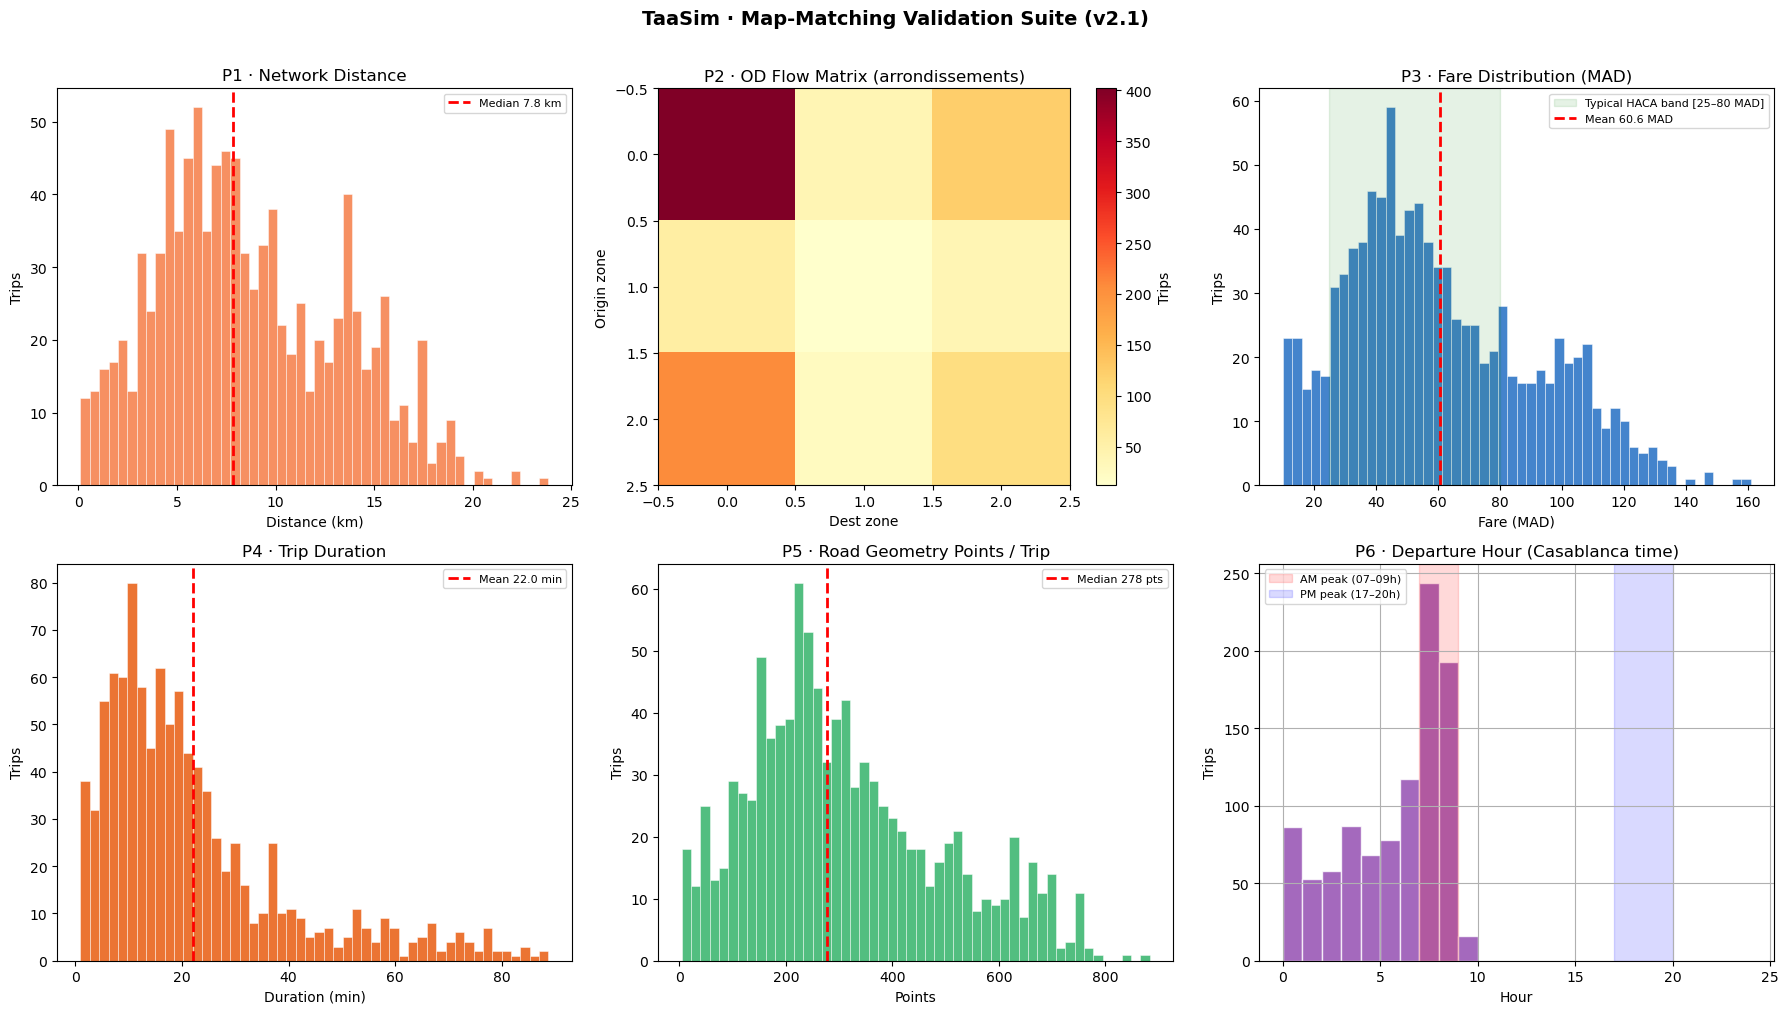

✅ Saved: validation_03_mapping_v2.png


In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("TaaSim · Map-Matching Validation Suite (v2.1)",
             fontsize=14, fontweight="bold", y=1.01)

# P1: Distance distribution
ax = axes[0, 0]
_d = final_pdf["distance_km"].dropna()
_d = _d[(_d > 0.1) & (_d < 40)]
ax.hist(_d, bins=50, color="#f4743b", alpha=0.8, edgecolor="white", lw=0.4)
ax.axvline(_d.median(), color="red", ls="--", lw=2, label=f"Median {_d.median():.1f} km")
ax.set(xlabel="Distance (km)", ylabel="Trips", title="P1 · Network Distance"); ax.legend(fontsize=8)

# P2: OD flow heatmap between arrondissements
ax = axes[0, 1]
if {"origin_zone", "destination_zone"}.issubset(final_pdf.columns):
    od = pd.crosstab(final_pdf["origin_zone"], final_pdf["destination_zone"])
    im = ax.imshow(od.values, aspect="auto", cmap="YlOrRd")
    ax.set(title="P2 · OD Flow Matrix (arrondissements)",
           xlabel="Dest zone", ylabel="Origin zone")
    fig.colorbar(im, ax=ax, label="Trips")

# P3: Fare distribution
ax = axes[0, 2]
_f = final_pdf["fare_mad"].dropna()
_f = _f[_f < 300]
ax.hist(_f, bins=50, color="#1565C0", alpha=0.8, edgecolor="white", lw=0.4)
ax.axvspan(25, 80, alpha=0.1, color="green", label="Typical HACA band [25–80 MAD]")
ax.axvline(_f.mean(), color="red", ls="--", lw=2, label=f"Mean {_f.mean():.1f} MAD")
ax.set(title="P3 · Fare Distribution (MAD)", xlabel="Fare (MAD)", ylabel="Trips")
ax.legend(fontsize=8)

# P4: Duration distribution
ax = axes[1, 0]
_dur = final_pdf["duration_sec"].dropna() / 60
_dur = _dur[_dur < 90]
ax.hist(_dur, bins=50, color="#E65100", alpha=0.8, edgecolor="white", lw=0.4)
ax.axvline(_dur.mean(), color="red", ls="--", lw=2, label=f"Mean {_dur.mean():.1f} min")
ax.set(title="P4 · Trip Duration", xlabel="Duration (min)", ylabel="Trips")
ax.legend(fontsize=8)

# P5: Road geometry points per trip (fidelity indicator)
ax = axes[1, 1]
if "n_road_points" in mapped_pdf.columns:
    _rp = mapped_pdf["n_road_points"]
    ax.hist(_rp, bins=50, color="#27ae60", alpha=0.8, edgecolor="white", lw=0.4)
    ax.axvline(_rp.median(), color="red", ls="--", lw=2,
               label=f"Median {_rp.median():.0f} pts")
    ax.set(title="P5 · Road Geometry Points / Trip",
           xlabel="Points", ylabel="Trips")
    ax.legend(fontsize=8)

# P6: Departure hour distribution (demand curve)
ax = axes[1, 2]
if "trip_hour" in mapped_pdf.columns:
    mapped_pdf["trip_hour"].hist(bins=24, range=(0, 24), ax=ax,
                                  color="#8e44ad", alpha=0.8, edgecolor="white")
    # Shade peak hours
    ax.axvspan(7, 9,  alpha=0.15, color="red",  label="AM peak (07–09h)")
    ax.axvspan(17, 20, alpha=0.15, color="blue", label="PM peak (17–20h)")
    ax.set(title="P6 · Departure Hour (Casablanca time)",
           xlabel="Hour", ylabel="Trips")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("validation_03_mapping_v2.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: validation_03_mapping_v2.png")

## §9 · Interactive Folium Maps

### Map A — Trip-origin heatmap + real arrondissement polygons
### Map B — Sample of 100 road-snapped routes on Casablanca streets
### Map C — Population choropleth by arrondissement (RGPH 2024)

In [14]:
# ── Map A: Origins heatmap + arrondissement boundaries ───────────────────────
CENTER = [zones_gdf["centroid_lat"].mean(), zones_gdf["centroid_lon"].mean()]
ZONE_COLORS = [
    "#e74c3c","#3498db","#2ecc71","#f39c12","#9b59b6","#1abc9c",
    "#e67e22","#2980b9","#27ae60","#c0392b","#8e44ad","#16a085",
    "#d35400","#2c3e50","#f1c40f","#7f8c8d",
]

m1 = folium.Map(location=CENTER, zoom_start=12, tiles="CartoDB positron")

# Trip-origin heatmap
heat_data = (
    mapped_pdf[["origin_lat", "origin_lon"]].dropna()
    .sample(n=min(15_000, len(mapped_pdf)), random_state=42)
    .values.tolist()
)
HeatMap(heat_data, radius=10, blur=8, min_opacity=0.3,
        name="Trip Origins Heatmap").add_to(m1)

# Arrondissement polygon boundaries (real OSM or bbox fallback)
for idx, (_, r) in enumerate(zones_gdf.iterrows()):
    color = ZONE_COLORS[idx % len(ZONE_COLORS)]
    folium.GeoJson(
        r.geometry.__geo_interface__,
        style_function=lambda x, c=color: {
            "fillOpacity": 0.10, "fillColor": c,
            "color": c, "weight": 2.5,
        },
        tooltip=folium.Tooltip(
            f"<b>{r['zone_name']}</b><br>"
            f"Population: {r['population']:,}<br>Zone ID: {r['zone_id']}",
            sticky=True,
        ),
        name=f"Zone: {r['zone_name']}",
    ).add_to(m1)
    folium.Marker(
        location=[r["centroid_lat"], r["centroid_lon"]],
        icon=folium.DivIcon(html=f"""
            <div style="font-size:9px;font-weight:bold;color:{color};
                        text-shadow:1px 1px 2px white,-1px -1px 2px white;
                        white-space:nowrap;">{r['zone_name']}</div>"""),
    ).add_to(m1)

# Casablanca landmarks
for lm in CASA_LANDMARKS:
    folium.Marker([lm["lat"], lm["lon"]], tooltip=lm["name"],
                  icon=folium.Icon(color="red", icon=lm["icon"], prefix="glyphicon")).add_to(m1)

folium.LayerControl(collapsed=False).add_to(m1)
print(f"🗺️  Map A: {len(heat_data):,} origins | {len(zones_gdf)} arrondissement polygons")
m1

🗺️  Map A: 1,000 origins | 16 arrondissement polygons


In [15]:
# ── Map B: Road-snapped route polylines (sample 100 trips) ───────────────────
TRIP_COLORS = [
    "#e6194b","#3cb44b","#4363d8","#f58231","#911eb4",
    "#42d4f4","#f032e6","#bfef45","#fabed4","#469990",
    "#dcbeff","#9A6324","#800000","#aaffc3","#808000","#000075",
]

m2 = folium.Map(location=CENTER, zoom_start=12, tiles="OpenStreetMap")
_sample = mapped_pdf.sample(min(100, len(mapped_pdf)), random_state=42)

for idx, (_, row) in enumerate(_sample.iterrows()):
    try:
        _pl = row["polyline"]
        _pl = json.loads(_pl) if isinstance(_pl, str) else _pl
        if not _pl or len(_pl) < 2:
            continue
        coords_ll = [[p[1], p[0]] for p in _pl]   # [lat, lon] for folium
        color = TRIP_COLORS[idx % len(TRIP_COLORS)]
        folium.PolyLine(
            coords_ll, weight=2.5, opacity=0.7, color=color,
            tooltip=(
                f"Trip {row['trip_id']} | {row['distance_km']:.1f} km | "
                f"{row['fare_mad']:.0f} MAD | {row['origin_zone_name']} → {row['destination_zone_name']}"
            ),
        ).add_to(m2)
        folium.CircleMarker(coords_ll[0],  radius=4, color="green", fill=True).add_to(m2)
        folium.CircleMarker(coords_ll[-1], radius=4, color="red",   fill=True).add_to(m2)
    except Exception:
        pass

for lm in CASA_LANDMARKS:
    folium.Marker([lm["lat"], lm["lon"]], tooltip=lm["name"],
                  icon=folium.Icon(color="orange", icon=lm["icon"], prefix="glyphicon")).add_to(m2)

print(f"🛣️  Map B: {len(_sample)} road-snapped trips on Casablanca streets")
m2

🛣️  Map B: 100 road-snapped trips on Casablanca streets


In [16]:
# ── Map C: Population choropleth per arrondissement ───────────────────────────
m3 = folium.Map(location=CENTER, zoom_start=12, tiles="CartoDB dark_matter")

pop_vals = zones_gdf["population"]
colormap = cm.LinearColormap(
    colors=["#ffffb2", "#fecc5c", "#fd8d3c", "#f03b20", "#bd0026"],
    vmin=pop_vals.min(), vmax=pop_vals.max(),
    caption="Population (RGPH-2024 projection)",
)
colormap.add_to(m3)

for _, r in zones_gdf.iterrows():
    pop   = r["population"]
    color = colormap(pop)
    folium.GeoJson(
        r.geometry.__geo_interface__,
        style_function=lambda x, c=color: {
            "fillColor": c, "fillOpacity": 0.65,
            "color": "white", "weight": 2,
        },
        tooltip=folium.Tooltip(
            f"<b>{r['zone_name']}</b><br>Population: <b>{pop:,}</b><br>Zone ID: {r['zone_id']}",
            sticky=True,
        ),
    ).add_to(m3)
    folium.Marker(
        location=[r["centroid_lat"], r["centroid_lon"]],
        icon=folium.DivIcon(html=f"""
            <div style="font-size:10px;font-weight:bold;color:white;
                        text-shadow:1px 1px 3px black,-1px -1px 3px black;
                        text-align:center;white-space:nowrap;">
                {r['zone_name']}<br>
                <span style="font-size:12px;">{pop:,}</span>
            </div>"""),
    ).add_to(m3)

for lm in CASA_LANDMARKS:
    folium.Marker([lm["lat"], lm["lon"]], tooltip=lm["name"],
                  icon=folium.Icon(color="lightgray", icon=lm["icon"], prefix="glyphicon")).add_to(m3)

print(f"🏙️  Map C: {len(zones_gdf)} arrondissements | "
      f"{pop_vals.min():,} (Mechouar) → {pop_vals.max():,} (max)")
display(
    zones_gdf[["zone_name", "population"]]
    .sort_values("population", ascending=False)
    .reset_index(drop=True)
)
m3

🏙️  Map C: 16 arrondissements | 2,101 (Mechouar) → 551,443 (max)


,zone_name,population
0,Sidi Moumen,551443
1,Hay Hassani,537509
2,Moulay Rachid,475000
3,Ain Chock,374707
4,Ain Sebaa,155828
5,Sidi Bernoussi,154919
6,Maarif,139669
7,Sidi Belyout,138294
8,El Fida,125933
9,Ben Msik,105612


## §10 · Formal Validation Suite

In [17]:
_PASS = "✅ PASS"
_FAIL = "⚠️  FAIL"
_checks: List[Tuple[str, bool]] = []

def check(label: str, cond: bool, detail: str = "") -> None:
    status = _PASS if cond else _FAIL
    detail_str = f"  [{detail}]" if detail else ""
    print(f"  {status}  {label}{detail_str}")
    _checks.append((label, cond))

print("=" * 68)
print("§10  TaaSim-03 · Map-Matching Validation Suite v2.1")
print("=" * 68)

_d   = mapped_pdf["distance_km"].dropna()
_f   = mapped_pdf["fare_mad"].dropna()
_dur = mapped_pdf["duration_sec"].dropna() / 60

# ── Output completeness ───────────────────────────────────────────────────────
print("\n▸ Output completeness")
check("At least 100 trips mapped", len(mapped_pdf) >= 100,
      f"{len(mapped_pdf):,} trips")
check("polyline column non-null",
      mapped_pdf["polyline"].notna().all(),
      f"{mapped_pdf['polyline'].isna().sum()} nulls")
check("trip_id is unique",
      mapped_pdf["trip_id"].nunique() == len(mapped_pdf),
      f"{mapped_pdf['trip_id'].nunique()} unique IDs")

# ── Coordinate sanity (all points within Casablanca bounds) ──────────────────
print("\n▸ Coordinate sanity (Casablanca lat 33.35–33.72°N, lon −7.85–−7.35°W)")
lat_ok = mapped_pdf["origin_lat"].between(CASA_LAT_MIN - 0.05, CASA_LAT_MAX + 0.05)
lon_ok = mapped_pdf["origin_lon"].between(CASA_LON_MIN - 0.05, CASA_LON_MAX + 0.05)
check("Origin lats within Casablanca bounds",
      lat_ok.mean() > 0.95, f"{lat_ok.mean():.1%} in bounds")
check("Origin lons within Casablanca bounds",
      lon_ok.mean() > 0.95, f"{lon_ok.mean():.1%} in bounds")

# ── Distance realism ──────────────────────────────────────────────────────────
print("\n▸ Distance realism (Casablanca petit-taxi typical range)")
check("Median distance ∈ [1.0, 12.0] km",
      1.0 <= _d.median() <= 12.0, f"median={_d.median():.2f} km")
check("Mean distance ∈ [1.5, 12.0] km",
      1.5 <= _d.mean() <= 12.0, f"mean={_d.mean():.2f} km")
check("95th-percentile < 30 km",
      _d.quantile(0.95) < 30, f"p95={_d.quantile(0.95):.2f} km")
check("No negative distances",
      (_d >= 0).all(), f"min={_d.min():.4f} km")

# ── Fare realism ──────────────────────────────────────────────────────────────
print("\n▸ Fare realism (Arrêté n° 3-71-19, 2024)")
check("All fares ≥ minimum fare (10 MAD)",
      (_f >= MIN_FARE - 0.01).all(), f"min={_f.min():.1f} MAD")
check("Mean fare ∈ [20, 200] MAD",
      20 <= _f.mean() <= 200, f"mean={_f.mean():.1f} MAD")

# ── Duration realism ──────────────────────────────────────────────────────────
print("\n▸ Duration realism")
check("All durations ≥ 1 min",
      (_dur >= 1.0).all(), f"min={_dur.min():.1f} min")
check("Mean duration ∈ [3, 60] min",
      3 <= _dur.mean() <= 60, f"mean={_dur.mean():.1f} min")

# ── Mapping quality ───────────────────────────────────────────────────────────
print("\n▸ Mapping quality")
check("Median road points ≥ 5",
      mapped_pdf["n_road_points"].median() >= 5,
      f"median={mapped_pdf['n_road_points'].median():.0f} pts")
check("All road-point counts ≥ 2",
      (mapped_pdf["n_road_points"] >= 2).all(),
      f"min={mapped_pdf['n_road_points'].min()}")

# ── Zone coverage ─────────────────────────────────────────────────────────────
print("\n▸ Zone coverage (arrondissements)")
n_origin_zones = mapped_pdf["origin_zone"].nunique()
check("Origin zones ≥ 10 (good spatial spread)",
      n_origin_zones >= 10, f"{n_origin_zones} zones used")
check("No null origin zones (fallback worked)",
      mapped_pdf["origin_zone"].notna().all(),
      f"{mapped_pdf['origin_zone'].isna().sum()} nulls")

# ── Timestamp sanity ──────────────────────────────────────────────────────────
print("\n▸ Timestamp sanity (shifted to 2024)")
ts_2024_start = int(pd.Timestamp("2024-01-01", tz="UTC").timestamp())
ts_2024_end   = int(pd.Timestamp("2025-01-01", tz="UTC").timestamp())
ts_in_2024 = mapped_pdf["timestamp"].between(ts_2024_start, ts_2024_end)
check("≥ 90% of timestamps fall in year 2024",
      ts_in_2024.mean() >= 0.90, f"{ts_in_2024.mean():.1%}")

# ── H3 ────────────────────────────────────────────────────────────────────────
if H3_AVAILABLE and "h3_origin" in mapped_pdf.columns:
    print("\n▸ H3 hex coverage")
    n_hex = mapped_pdf["h3_origin"].nunique()
    check(f"H3 origin hexes ≥ 10 (spatial granularity)",
          n_hex >= 10, f"{n_hex} unique hexes")

# ── Summary ───────────────────────────────────────────────────────────────────
n_pass = sum(c for _, c in _checks)
n_total = len(_checks)
print(f"\n{'='*68}")
print(f"  RESULT: {n_pass}/{n_total} checks passed  "
      f"({'✅ ALL PASS' if n_pass == n_total else '⚠️  SOME FAILURES — review above'})")
print(f"  Total mapped trips : {len(mapped_pdf):,}")
print(f"  Output path        : {output_path}")
print(f"{'='*68}")

§10  TaaSim-03 · Map-Matching Validation Suite v2.1

▸ Output completeness
  ✅ PASS  At least 100 trips mapped  [1,000 trips]
  ✅ PASS  polyline column non-null  [0 nulls]
  ✅ PASS  trip_id is unique  [1000 unique IDs]

▸ Coordinate sanity (Casablanca lat 33.35–33.72°N, lon −7.85–−7.35°W)
  ✅ PASS  Origin lats within Casablanca bounds  [100.0% in bounds]
  ✅ PASS  Origin lons within Casablanca bounds  [100.0% in bounds]

▸ Distance realism (Casablanca petit-taxi typical range)
  ✅ PASS  Median distance ∈ [1.0, 12.0] km  [median=7.82 km]
  ✅ PASS  Mean distance ∈ [1.5, 12.0] km  [mean=8.60 km]
  ✅ PASS  95th-percentile < 30 km  [p95=17.10 km]
  ✅ PASS  No negative distances  [min=0.0429 km]

▸ Fare realism (Arrêté n° 3-71-19, 2024)
  ✅ PASS  All fares ≥ minimum fare (10 MAD)  [min=10.0 MAD]
  ✅ PASS  Mean fare ∈ [20, 200] MAD  [mean=60.6 MAD]

▸ Duration realism
  ✅ PASS  All durations ≥ 1 min  [min=1.0 min]
  ✅ PASS  Mean duration ∈ [3, 60] min  [mean=22.3 min]

▸ Mapping quality
  ✅ P

## §11 · Pipeline Summary

### Output columns

| Column | Type | Description |
|---|---|---|
| `trip_id` | int | Sequential 1-based ID |
| `taxi_id` | int | Anonymised fleet index (1–5 000) |
| `timestamp` | long | UTC Unix (shifted to 2024) |
| `day_type` | str | A=weekday, B=holiday |
| `call_type` | str | A=dispatched, B=taxi stand, C=street hail |
| `origin/destination_zone` | int | Arrondissement ID (1–16) |
| `origin/destination_zone_name` | str | Arrondissement name |
| `origin/dest_lon/lat` | double | Road-snapped GPS (anonymised centroid zone level for Flink Job 1) |
| `h3_origin/h3_dest` | str | H3 res-8 hex cell (~0.74 km²) |
| `polyline` | str | JSON-encoded road geometry `[[lon,lat],…]` |
| `distance_km` | double | OSM network distance |
| `duration_sec` | long | With directional congestion model |
| `fare_mad` | double | Arrêté n° 3-71-19 (rounded to 0.50 MAD) |
| `n_road_points` | int | Road geometry fidelity (number of OSM coordinates) |
| `n_segments` | int | Number of OSM edges in route |
| `is_cbd_bound` | bool | True if trip bearing within 60° of CBD |
| `trip_hour` | int | Departure hour 0–23 (Casablanca time) |

### What feeds into TaaSim downstream

| Consumer | Column(s) used |
|---|---|
| **Flink Job 1** (GPS Normalizer) | `origin_lon/lat`, `destination_zone`, `timestamp` |
| **Flink Job 2** (Demand Aggregator) | `origin_zone`, `trip_hour` |
| **Flink Job 3** (Trip Matcher) | `origin_zone`, `destination_zone`, `taxi_id`, `distance_km` |
| **Spark ML** (Demand Forecasting) | `origin_zone`, `trip_hour`, `day_type`, `call_type`, `fare_mad` |
| **Grafana** (Heatmap) | `origin_lon/lat`, `origin_zone`, `destination_zone` |

---

> **References**  
> - HACA (2019). *Enquête d'Opinions sur les Transports Urbains au Maroc.*  
> - Arrêté n° 3-71-19 (2024). *Tarifs des petits taxis au Maroc.*  
> - Moreira-Matias et al., 'Predicting Taxi-Passenger Demand Using Streaming Data' — IEEE Trans. ITS, 2013.  
> - OpenStreetMap contributors (2024). *Casablanca road network* via OSMNX.